In [1]:
from pathlib import Path
import pandas as pd
import subprocess
import matplotlib.pyplot as plt
import sys
import matplotlib as mpl
import ast
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import numpy as np
sys.path.append('../functions')
from peptide_annotator import get_peptide_lengths, proteome_to_dict, create_fasta_dict, annotate_peptides, add_positions
from data_inspection import length_distribution
from waterfall import response_heatmap

# Analyze T-cell responses to Chronic lymphocytic leukemia warehouse with epicore
Data used in this notebook:
- Immunopeptidome benign reference dataset, comprising data from the [HLA-Ligand atlas](https://jitc.bmj.com/content/9/4/e002071), a [benign reference dataset from Hoenisch Gravel et al.](https://www.nature.com/articles/s41467-023-42692-7) and a [benign reference dataset from Scheid et al.](https://link.springer.com/article/10.1186/s13059-025-03763-8).  
- Malignant dataset: The malignant data used in this note book is the data from ["Personalised multipeptide-based T-cell activator for chronic lymphocytic leukaemia: an open-label, single-centre, phase 1 study"](https://doi.org/10.1016/S2352-3026(25)00323-0) .

## Prepare data for epicore

In [2]:
# Load allotype information
patient_mapping = pd.read_csv('/mnt/volume/jana/thesis/data/CLL_clinicalstudy/new_CLL/table.tsv', sep='\t')
allotypes = []
for dir in Path('/mnt/volume/jana/thesis/data/CLL_clinicalstudy/new_CLL/').iterdir():
    for file in dir.glob('HLA_Typ*.txt'): 
        patient_id = str(file).split('/')[-2]
        allotype = pd.read_csv(file,sep=', ', engine='python')
        allotypes.append([patient_id,'~'.join(allotype.columns.values)])

allotypes_df = pd.DataFrame(allotypes,columns=['patient_id','allotypes'])
allotypes_df = pd.merge(allotypes_df, patient_mapping, left_on='patient_id',right_on='Patient ID', how='left')
allotypes_df = allotypes_df[~allotypes_df['UPN'].isnull()]

In [3]:
# Prepare data (classI)
class1_timstof_df = pd.read_excel('/mnt/volume/jana/thesis/data/CLL_clinicalstudy/databases/timstof/Database_timsTOF_I.xlsx')
class1_timstof_df = class1_timstof_df.rename(columns={'Sequence':'sequence','Protein ID':'accessions','Sample Name':'sample'})
class1_timstof_df['sample'] = class1_timstof_df['sample'].str.replace('_','-')
class1_lumos_df = pd.read_excel('/mnt/volume/jana/thesis/data/CLL_clinicalstudy/databases/lumos/Database_Lumos_I.xlsx')
class1_lumos_df = class1_lumos_df.rename(columns={'Sequence':'sequence','Protein Group Accessions':'accessions','Source_File':'sample'})
class1_lumos_df['sample'] = class1_lumos_df['sample'].apply(lambda cell: cell.split('_')[0])
class1_malignant_df = pd.concat([class1_timstof_df,class1_lumos_df])
class1_malignant_df = class1_malignant_df[['sequence','accessions','sample']]
class1_malignant_df = pd.merge(class1_malignant_df, allotypes_df, left_on='sample', right_on='Patient ID', how='left')
class1_malignant_df = class1_malignant_df[~class1_malignant_df['UPN'].isnull()]
class1_malignant_df = class1_malignant_df.drop(columns={'patient_id', 'Patient ID', 'sample'})
class1_malignant_df['sequence'] = class1_malignant_df['sequence'].str.replace('m','M')
class1_malignant_df = class1_malignant_df.rename(columns={'UPN':'sample'})
class1_malignant_df['condition'] = 'malignant'
class1_malignant_df['mhc_class'] = 'I'

In [4]:
# Prepare data (classII)
class2_timstof_df = pd.read_excel('/mnt/volume/jana/thesis/data/CLL_clinicalstudy/databases/timstof/Database_timsTOF_II.xlsx')
class2_timstof_df = class2_timstof_df.rename(columns={'Peptide':'sequence','Protein ID':'accessions','Sample':'sample'})
class2_timstof_df['sample'] = class2_timstof_df['sample'].str.replace('_','-')
class2_lumos_df = pd.read_excel('/mnt/volume/jana/thesis/data/CLL_clinicalstudy/databases/lumos/Database_Lumos_II.xlsx')
class2_lumos_df = class2_lumos_df.rename(columns={'Sequence':'sequence','Protein Group Accessions':'accessions','Source_File':'sample'})
class2_lumos_df['sample'] = class2_lumos_df['sample'].apply(lambda cell: cell.split('_')[0])
class2_malignant_df = pd.concat([class2_timstof_df,class2_lumos_df])
class2_malignant_df = class2_malignant_df[['sequence','accessions','sample']]
class2_malignant_df = pd.merge(class2_malignant_df, allotypes_df, left_on='sample', right_on='Patient ID', how='left')
class2_malignant_df = class2_malignant_df[~class2_malignant_df['UPN'].isnull()]
class2_malignant_df = class2_malignant_df.drop(columns={'patient_id', 'Patient ID', 'sample'})
class2_malignant_df['sequence'] = class2_malignant_df['sequence'].str.replace('m','M')
class2_malignant_df = class2_malignant_df.rename(columns={'UPN':'sample'})
class2_malignant_df['condition'] = 'malignant'
class2_malignant_df['mhc_class'] = 'II'

In [5]:
# load benign data
benign_df = pd.read_csv('/mnt/volume/jana/thesis/data/newbenign/benign_HLA_Ligand_Atlas_Lumos_timsTOF.tsv',sep='\t')[['peptide_sequence','mhc_class','dignity','donor_code','all_hla_alleles_donor','biological_material_name','qbic_project_code']]
benign_df = benign_df.rename(columns={'peptide_sequence':'sequence','donor_code':'sample','all_hla_alleles_donor':'HLA Typing', 'dignity':'condition'})
benign_df = benign_df.drop_duplicates(['sequence','mhc_class','condition','sample','HLA Typing'])
benign_df['sample'] = benign_df['sample']+'_'+benign_df['biological_material_name']

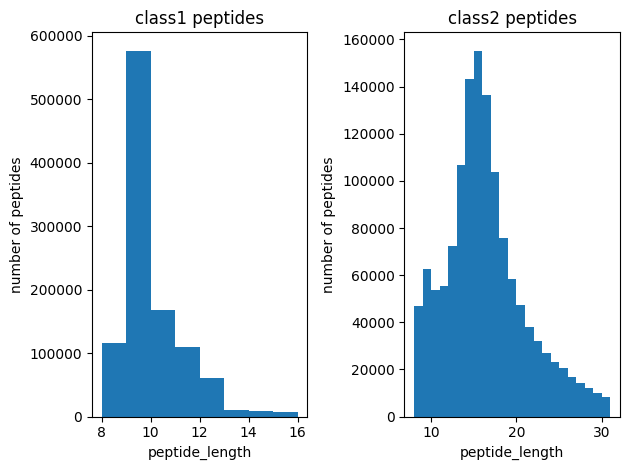

In [6]:
# Annotate peptides
immunopeptidomes_df = pd.concat([class2_malignant_df, class1_malignant_df, benign_df])
immunopeptidomes_df['sequence'] = immunopeptidomes_df['sequence'].str.replace('(Oxidation)','')
lengths = get_peptide_lengths(immunopeptidomes_df)
proteome_dict = proteome_to_dict('/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta')
fasta_dict = create_fasta_dict(proteome_dict, lengths)
immunopeptidomes_df = annotate_peptides(fasta_dict, immunopeptidomes_df)
immunopeptidomes_df = add_positions(proteome_dict, immunopeptidomes_df,'accessions','sequence')
class1_df = immunopeptidomes_df[(immunopeptidomes_df['mhc_class']=='I')&(immunopeptidomes_df['sequence'].str.len()<16)]
class2_df = immunopeptidomes_df[immunopeptidomes_df['mhc_class']=='II']
class1_df.to_csv('CLL_HEITMANN_class1.csv')
class2_df.to_csv('CLL_HEITMANN_class2.csv')
length_distribution(class1_df[class1_df['accessions']!='unmapped'], class2_df[class2_df['accessions']!='unmapped'])

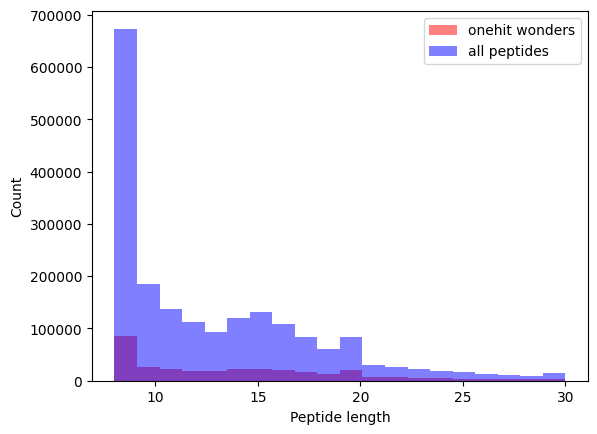

Removed 700528 onehit wonders (499695 benign, 200833 malignant).


In [ ]:
########################
# remove one-hit wonders
########################
#immunopeptidomes_df = pd.concat([class2_malignant_df, class1_malignant_df, benign_df])
#immunopeptidomes_df['sequence'] = immunopeptidomes_df['sequence'].str.replace('(Oxidation)','')
#immunopeptidomes_df = immunopeptidomes_df[~immunopeptidomes_df[['sequence', 'sample', 'biological_material_name','mhc_class']].duplicated(keep='first')]
#plt.hist(immunopeptidomes_df[~immunopeptidomes_df.duplicated(subset=['sequence'], keep=False)]['sequence'].str.len(), label='onehit wonders', color='red', alpha=0.5, bins=20)
#plt.hist(immunopeptidomes_df[immunopeptidomes_df.duplicated(subset=['sequence'], keep=False)]['sequence'].str.len(), label='all peptides', color='blue', alpha=0.5, bins=20)
#plt.xlabel('Peptide length')
#plt.ylabel('Count')
#plt.legend()
#plt.show()
#print(f"Removed {len(immunopeptidomes_df[~immunopeptidomes_df.duplicated(subset=['sequence'])]['sequence'].unique())} onehit wonders ({len(immunopeptidomes_df[(~immunopeptidomes_df.duplicated(subset=['sequence'])&(immunopeptidomes_df['condition']=='benign'))]['sequence'].unique())} benign, {len(immunopeptidomes_df[(~immunopeptidomes_df.duplicated(subset=['sequence'])&(immunopeptidomes_df['condition']=='malignant'))]['sequence'].unique())} malignant).")
#immunopeptidomes_df = immunopeptidomes_df[immunopeptidomes_df.duplicated(subset=['sequence'], keep=False)]

## Run epicore
This part of the notebook runs epicore for class1 and class2 peptides.

In [2]:
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_HEITMANN_classI', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_HEITMANN_class1.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_HEITMANN_classI', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_HEITMANN_class1.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'], returncode=0)

In [3]:
subprocess.run(['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_HEITMANN_classII', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_HEITMANN_class2.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'])

CompletedProcess(args=['epicore', '--reference_proteome', '/mnt/volume/jana/thesis/data/CLL_warehouse_PXD024871/spHUMANwoi_130927_CLL_mut.fasta', '--out_dir', 'CLL_HEITMANN_classII', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--max_step_size', '5', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'CLL_HEITMANN_class2.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'], returncode=0)

## Analyze the T-cell response reported in the phase 1 study
For each warehouse peptide the by epicore identified peptide group is visualized.

In [4]:
# candidate and response data of the CLL study
A02_candidates = ['ALHRPDVYL','TLDTSKLYV','VIAELPPKV']
A02_response = [[],['UPN09'],[]]
A24_candidates = ['GYMPYLNRF','KYSKALIDYF','RHTGALPLF']
A24_response = [['UPN06'],[],['UPN02','UPN01','UPN03']]
B07_candidates = ['LPRLEALDL','RPSNKAPLL','SPRVYWLGL']
B07_response = [['UPN08','UPN12','UPN14','UPN16'],['UPN04'],['UPN08','UPN12','UPN14','UPN16']]
class2_candidates = ['AKPEASFQVWNKDSSSKNLIPR','QPPDWLQGHYLVVRYEDL','YPDRPGWLRYIQRTPYSDG']
class2_response = [['UPN01','UPN03','UPN05','UPN02','UPN04','UPN06','UPN07','UPN12','UPN16','UPN17','UPN20'],['UPN01','UPN03','UPN05','UPN10','UPN02','UPN04','UPN06','UPN07','UPN08','UPN11','UPN14','UPN16','UPN17'],['UPN01','UPN03','UPN05','UPN10','UPN02','UPN04','UPN06','UPN07','UPN08','UPN09','UPN11','UPN12','UPN13','UPN14','UPN16','UPN17']]

In [ ]:
df_1 = pd.read_csv('CLL_HEITMANN_class1.csv')
benign_allotypes = pd.read_csv('CLL_HEITMANN_class1.csv')[['sample', 'HLA Typing']].drop_duplicates()
benign_allotypes_dict = dict(zip(benign_allotypes['sample'],benign_allotypes['HLA Typing']))
all_benign_class1 = len([s for s in df_1['sample'].unique() if 'UPN' not in s])
all_benign_A02 = len([s for s in df_1['sample'].unique() if ('UPN' not in s) and ((type(benign_allotypes_dict[s])!=float)and('A*02' in benign_allotypes_dict[s]))])
all_benign_A24 = len([s for s in df_1['sample'].unique() if ('UPN' not in s) and ((type(benign_allotypes_dict[s])!=float)and('A*24' in benign_allotypes_dict[s]))])
all_benign_B07 = len([s for s in df_1['sample'].unique() if ('UPN' not in s) and ((type(benign_allotypes_dict[s])!=float)and('B*07' in benign_allotypes_dict[s]))])
all_benign_class2 = len([s for s in pd.read_csv('CLL_HEITMANN_class2.csv')['sample'].unique() if 'UPN' not in s])

In [ ]:
class1_df = pd.read_csv('CLL_HEITMANN_class1.csv')
class2_df = pd.read_csv('CLL_HEITMANN_class2.csv')

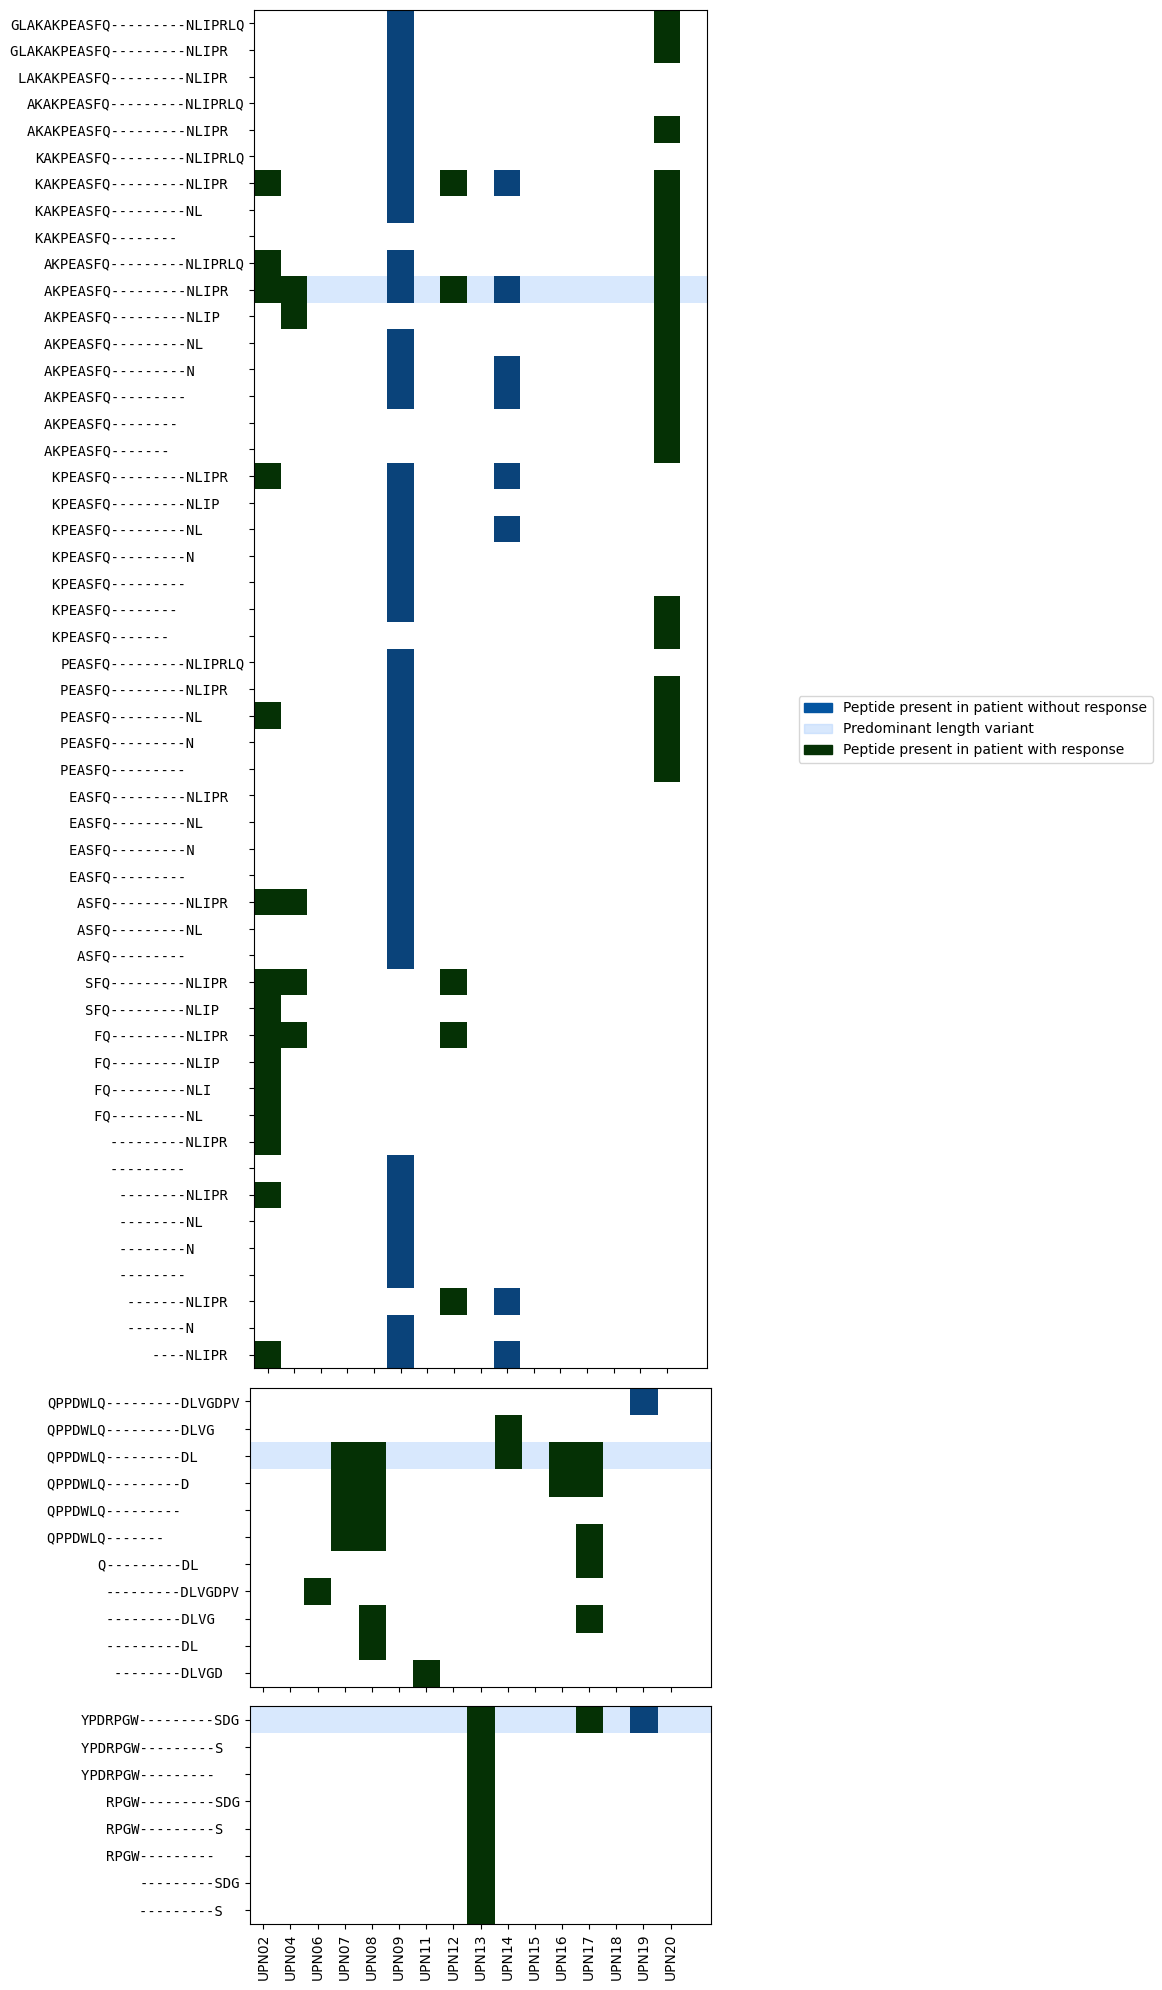

In [ ]:
# class2
c2_malignant = class2_df[class2_df['condition'].str.contains('malignant')]['sample'].unique()
fig, axis = plt.subplots(3,1, sharex=True, height_ratios=[50,11,8], figsize=(8,20))
for i, (candidate, response) in enumerate(zip(class2_candidates, class2_response)):
    im, legend_elements = response_heatmap('CLL_HEITMANN_classII/epitopes.csv', candidate, axis[i], 3, '', allotype_samples=c2_malignant,responses=response)

axis[0].legend(handles=legend_elements, bbox_to_anchor=(2,0.5))
plt.tight_layout()


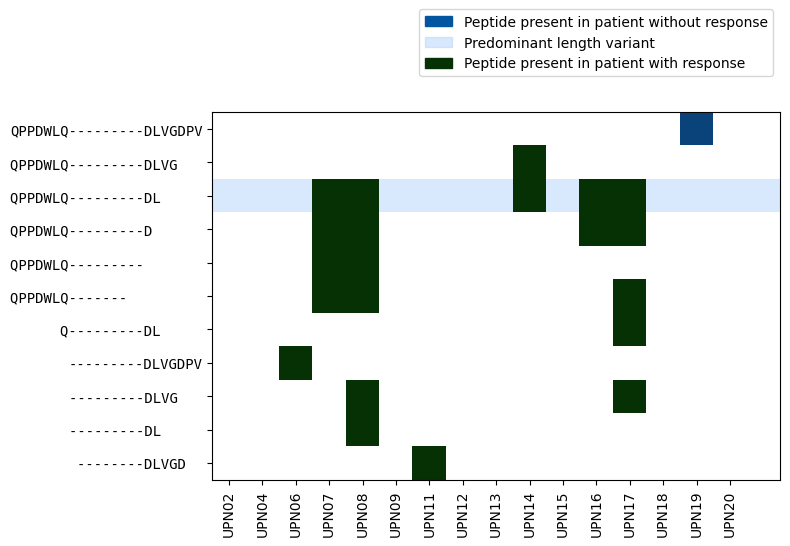

In [ ]:
c2_malignant = class2_df[class2_df['condition'].str.contains('malignant')]['sample'].unique()

fig, axis = plt.subplots(1,1, sharex=True, figsize=(8,20))
im, legend_elements = response_heatmap('CLL_HEITMANN_classII/epitopes.csv', class2_candidates[1], axis, 3, '', allotype_samples=c2_malignant,responses=class2_response[1])

axis.legend(handles=legend_elements, bbox_to_anchor=(1,1.3))
plt.tight_layout()

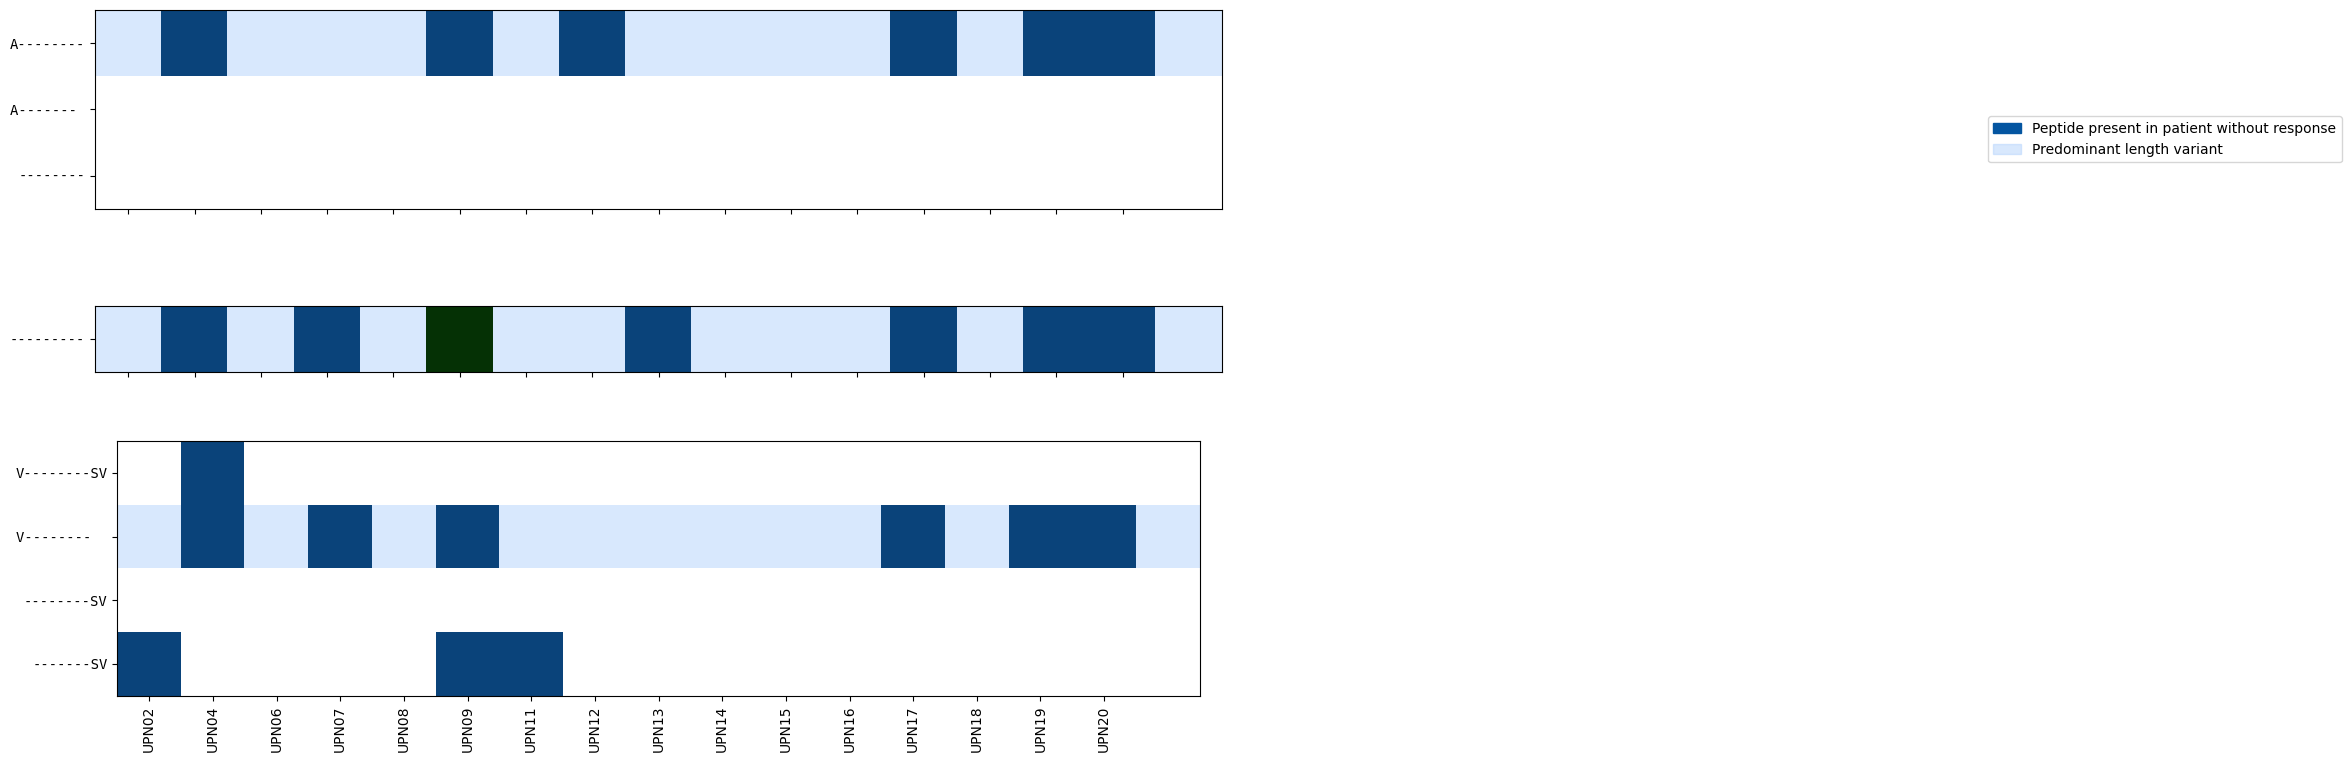

In [ ]:
# A02
c1_malignant = class1_df[class1_df['condition'].str.contains('malignant')]['sample'].unique()
fig, axis = plt.subplots(3,1, sharex=True,  figsize=(20,8))
for i, (candidate, response) in enumerate(zip(A02_candidates, A02_response)):
    im, legend_elements = response_heatmap('CLL_HEITMANN_classI/epitopes.csv', candidate, axis[i], 3, '', allotype_samples=c2_malignant,responses=response)

axis[0].legend(handles=legend_elements, bbox_to_anchor=(2,0.5))
plt.tight_layout()


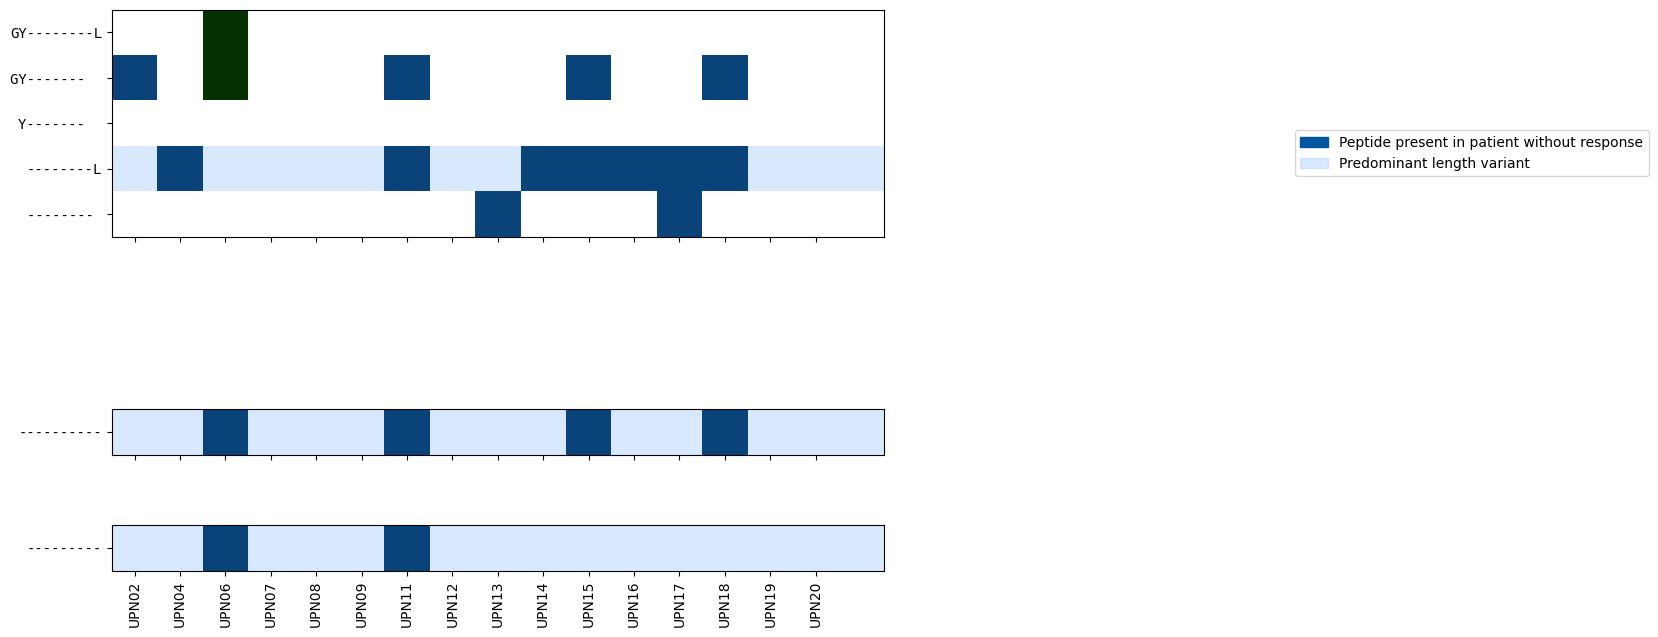

In [ ]:
# A24
c1_malignant = class1_df[class1_df['condition'].str.contains('malignant')]['sample'].unique()
fig, axis = plt.subplots(3,1, sharex=True, height_ratios=[5/7, 1/7, 1/7], figsize=(20,8))
for i, (candidate, response) in enumerate(zip(A24_candidates, A24_response)):
    im, legend_elements = response_heatmap('CLL_HEITMANN_classI/epitopes.csv', candidate, axis[i], 3, '', allotype_samples=c2_malignant,responses=response)

axis[0].legend(handles=legend_elements, bbox_to_anchor=(2,0.5))
plt.tight_layout()


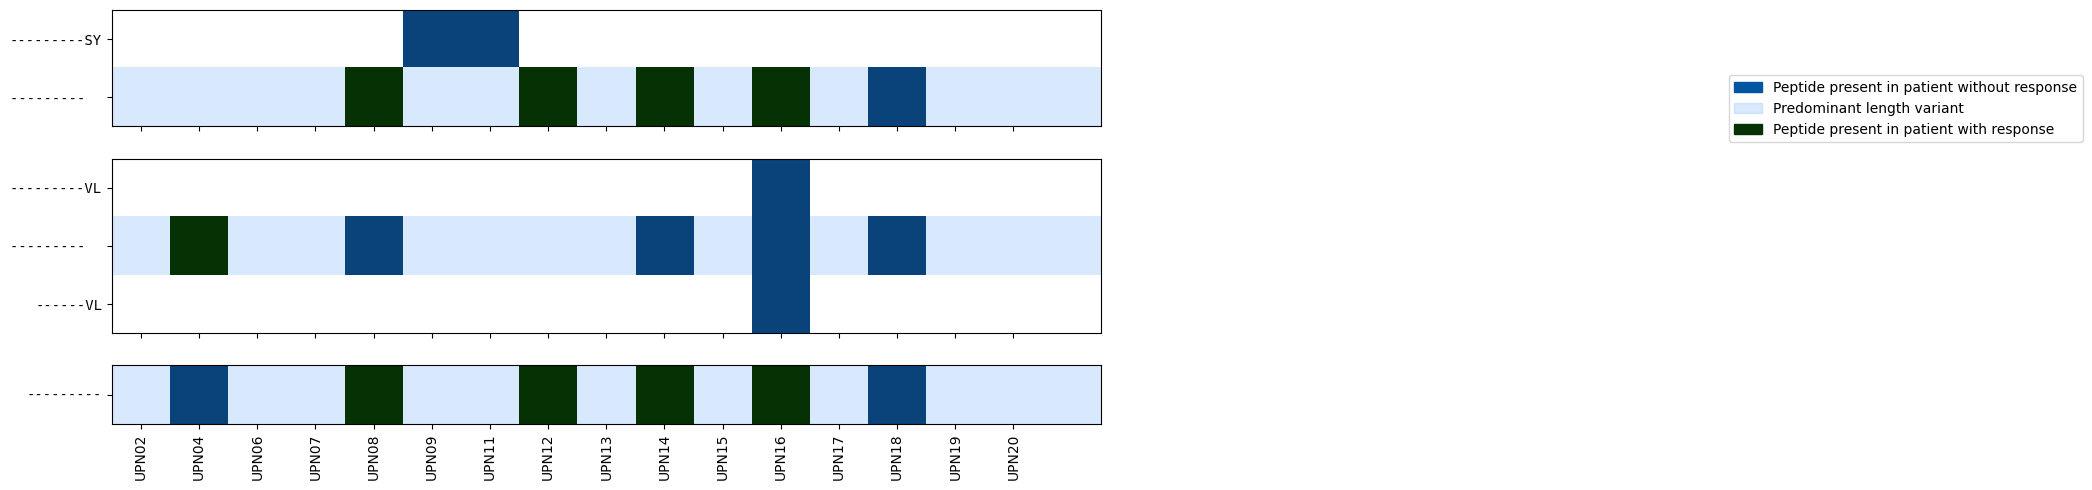

In [ ]:
# B07
c1_malignant = class1_df[class1_df['condition'].str.contains('malignant')]['sample'].unique()
fig, axis = plt.subplots(3,1, sharex=True, height_ratios=[1/3, 1/2, 1/6], figsize=(20,5))
for i, (candidate, response) in enumerate(zip(B07_candidates, B07_response)):
    im, legend_elements = response_heatmap('CLL_HEITMANN_classI/epitopes.csv', candidate, axis[i], 3, '', allotype_samples=c2_malignant,responses=response)

axis[0].legend(handles=legend_elements, bbox_to_anchor=(2,0.5))
plt.tight_layout()